In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "../data/cleaned/datapulse_sales_cleaned.csv"
)

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00.000000000,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896779,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793558,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690338,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587117,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [4]:
product_analysis = (
    df.groupby("product")
      .agg(
          Revenue=("net_sales", "sum"),
          Orders=("order_id", "nunique"),
          Units_Sold=("quantity", "sum"),
          Customers=("customer_id", "nunique"),
          Average_Order_Value=("net_sales", "mean"),
          Average_Unit_Price=("unit_price", "mean"),
          Average_Discount=("discount", "mean")
      )
      .sort_values(
          "Revenue",
          ascending=False
      )
)

In [5]:
product_analysis

,Revenue,Orders,Units_Sold,Customers,Average_Order_Value,Average_Unit_Price,Average_Discount
product,,,,,,,
Laptop,115261250.0,639,1917,357,180377.543036,65000.0,0.075822
Smartphone,71852000.0,649,1944,371,110711.864407,40000.0,0.077504
Tablet,50097000.0,602,1791,347,83217.607973,30000.0,0.069601
Monitor,26736750.0,651,1928,360,41070.276498,15000.0,0.073502
Webcam,6120625.0,616,1894,349,9936.079545,3500.0,0.075974
Headphones,4321375.0,633,1873,356,6826.816746,2500.0,0.077725
Keyboard,3398100.0,612,1835,360,5552.450980,2000.0,0.074755
Mouse,1307200.0,598,1769,329,2185.953177,800.0,0.075000


In [6]:
# Revenue Contribution
total_revenue = df["net_sales"].sum()

In [7]:
product_analysis["Revenue_Contribution"] = (
    product_analysis["Revenue"]
    / total_revenue
    * 100
)

In [8]:
product_analysis[
    "Revenue_Contribution"
] = product_analysis[
    "Revenue_Contribution"
].round(2)

In [9]:
product_analysis

,Revenue,Orders,Units_Sold,Customers,Average_Order_Value,Average_Unit_Price,Average_Discount,Revenue_Contribution
product,,,,,,,,
Laptop,115261250.0,639,1917,357,180377.543036,65000.0,0.075822,41.30
Smartphone,71852000.0,649,1944,371,110711.864407,40000.0,0.077504,25.74
Tablet,50097000.0,602,1791,347,83217.607973,30000.0,0.069601,17.95
Monitor,26736750.0,651,1928,360,41070.276498,15000.0,0.073502,9.58
Webcam,6120625.0,616,1894,349,9936.079545,3500.0,0.075974,2.19
Headphones,4321375.0,633,1873,356,6826.816746,2500.0,0.077725,1.55
Keyboard,3398100.0,612,1835,360,5552.450980,2000.0,0.074755,1.22
Mouse,1307200.0,598,1769,329,2185.953177,800.0,0.075000,0.47


In [10]:
# the revenue leader
top_revenue_product = (
    product_analysis["Revenue"]
    .idxmax()
)

top_revenue = (
    product_analysis["Revenue"]
    .max()
)

print("Top Revenue Product:", top_revenue_product)
print("Revenue: ₹", round(top_revenue, 2))

Top Revenue Product: Laptop
Revenue: ₹ 115261250.0


In [11]:
# the volume leader
top_volume_product = (
    product_analysis["Units_Sold"]
    .idxmax()
)

top_volume = (
    product_analysis["Units_Sold"]
    .max()
)

print("Top Volume Product:", top_volume_product)
print("Units Sold:", top_volume)

Top Volume Product: Smartphone
Units Sold: 1944


In [12]:
print(
    "Revenue Leader:",
    top_revenue_product
)

print(
    "Volume Leader:",
    top_volume_product
)

Revenue Leader: Laptop
Volume Leader: Smartphone


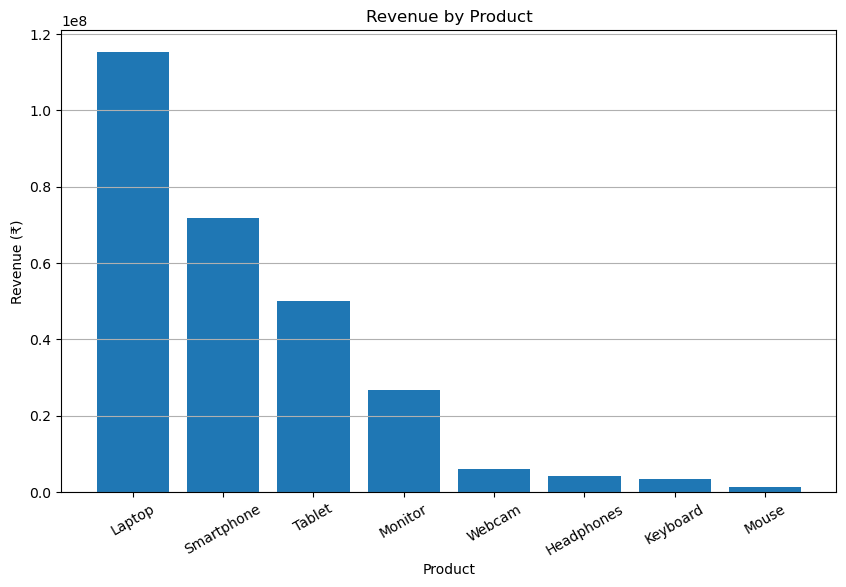

In [13]:
# Visualizing product revenue
plt.figure(figsize=(10, 6))

plt.bar(
    product_analysis.index,
    product_analysis["Revenue"]
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

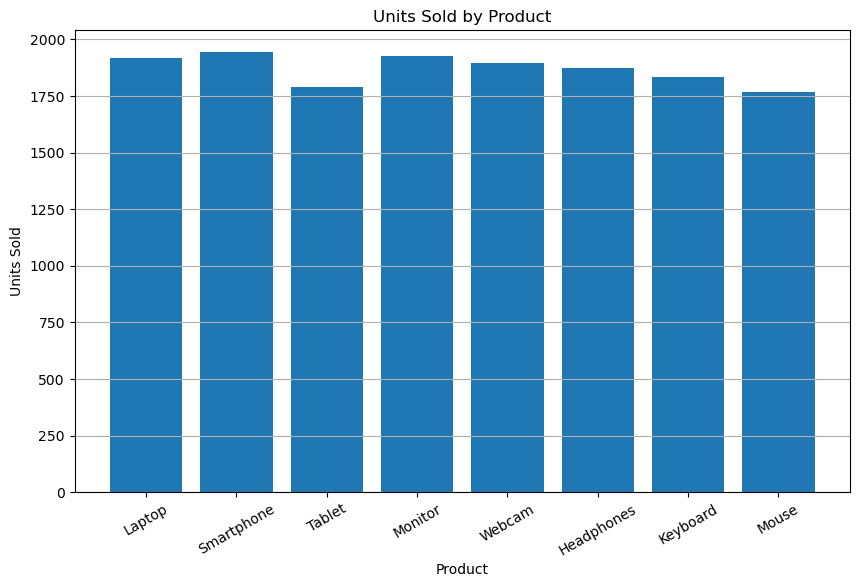

In [14]:
# Visualize product volume
plt.figure(figsize=(10, 6))

plt.bar(
    product_analysis.index,
    product_analysis["Units_Sold"]
)

plt.title("Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()


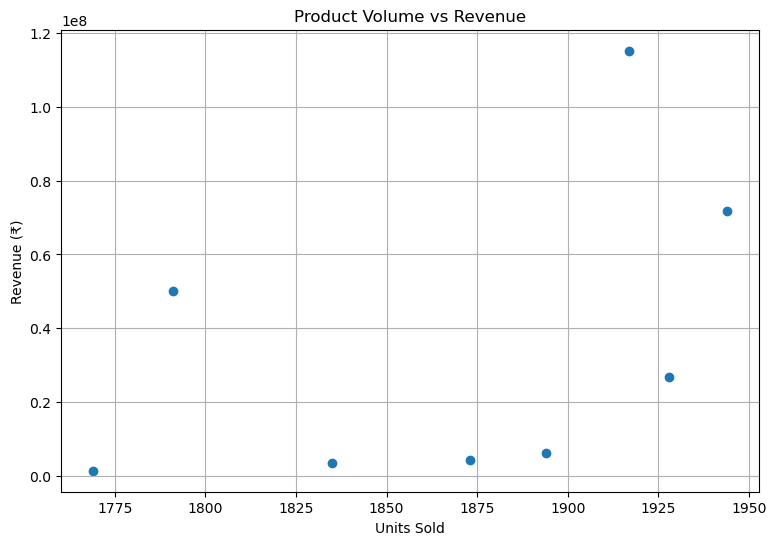

In [15]:
# Revenue vs Volume
plt.figure(figsize=(9, 6))

plt.scatter(
    product_analysis["Units_Sold"],
    product_analysis["Revenue"]
)

plt.title("Product Volume vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue (₹)")

plt.grid()

plt.show()

In [16]:
# correlation:
product_volume_revenue_corr = (
    product_analysis["Units_Sold"]
    .corr(product_analysis["Revenue"])
)

print(
    "Product Volume vs Revenue Correlation:",
    round(product_volume_revenue_corr, 3)
)

Product Volume vs Revenue Correlation: 0.456


In [17]:
# Product pricing analysis
product_analysis[
    [
        "Revenue",
        "Units_Sold",
        "Average_Unit_Price",
        "Average_Order_Value"
    ]
]

,Revenue,Units_Sold,Average_Unit_Price,Average_Order_Value
product,,,,
Laptop,115261250.0,1917,65000.0,180377.543036
Smartphone,71852000.0,1944,40000.0,110711.864407
Tablet,50097000.0,1791,30000.0,83217.607973
Monitor,26736750.0,1928,15000.0,41070.276498
Webcam,6120625.0,1894,3500.0,9936.079545
Headphones,4321375.0,1873,2500.0,6826.816746
Keyboard,3398100.0,1835,2000.0,5552.450980
Mouse,1307200.0,1769,800.0,2185.953177


In [18]:
# the highest-priced product:
highest_price_product = (
    product_analysis[
        "Average_Unit_Price"
    ].idxmax()
)

highest_price = (
    product_analysis[
        "Average_Unit_Price"
    ].max()
)

print(
    "Highest Average Unit Price:",
    highest_price_product
)

print(
    "Price: ₹",
    round(highest_price, 2)
)

Highest Average Unit Price: Laptop
Price: ₹ 65000.0


In [19]:
# Discount analysis
discount_by_product = (
    df.groupby("product")
      .agg(
          Average_Discount=("discount", "mean"),
          Revenue=("net_sales", "sum"),
          Orders=("order_id", "nunique")
      )
      .sort_values(
          "Average_Discount",
          ascending=False
      )
)

In [20]:
discount_by_product

,Average_Discount,Revenue,Orders
product,,,
Headphones,0.077725,4321375.0,633
Smartphone,0.077504,71852000.0,649
Webcam,0.075974,6120625.0,616
Laptop,0.075822,115261250.0,639
Mouse,0.075000,1307200.0,598
Keyboard,0.074755,3398100.0,612
Monitor,0.073502,26736750.0,651
Tablet,0.069601,50097000.0,602


In [21]:
# Product × Region analysis
product_region = pd.pivot_table(
    df,
    values="net_sales",
    index="product",
    columns="region",
    aggfunc="sum",
    fill_value=0
)

In [22]:
product_region

region,East,North,South,West
product,,,,
Headphones,985500.0,1073875.0,1222000.0,1040000.0
Keyboard,942700.0,750900.0,811300.0,893200.0
Laptop,31801250.0,26165750.0,26032500.0,31261750.0
Monitor,6772500.0,7197000.0,6780750.0,5986500.0
Mouse,344400.0,330320.0,327440.0,305040.0
Smartphone,17772000.0,16638000.0,20332000.0,17110000.0
Tablet,11889000.0,13974000.0,13066500.0,11167500.0
Webcam,1622950.0,1485050.0,1405950.0,1606675.0


In [23]:
# the strongest product in every region
regional_product_leader = (
    product_region.idxmax()
)

In [24]:
regional_product_leader

region
East     Laptop
North    Laptop
South    Laptop
West     Laptop
dtype: object

In [25]:
# Category-level analysis
category_analysis = (
    df.groupby("category")
      .agg(
          Revenue=("net_sales", "sum"),
          Units_Sold=("quantity", "sum"),
          Orders=("order_id", "nunique"),
          Customers=("customer_id", "nunique"),
          Average_Order_Value=("net_sales", "mean"),
          Average_Discount=("discount", "mean")
      )
      .sort_values(
          "Revenue",
          ascending=False
      )
)

In [26]:
category_analysis["Revenue_Contribution"] = (
    category_analysis["Revenue"]
    / total_revenue
    * 100
).round(2)

In [27]:
category_analysis

,Revenue,Units_Sold,Orders,Customers,Average_Order_Value,Average_Discount,Revenue_Contribution
category,,,,,,,
Electronics,263947000.0,7580,2541,500,103875.245966,0.074183,94.57
Accessories,15147300.0,7371,2459,495,6159.943066,0.075885,5.43


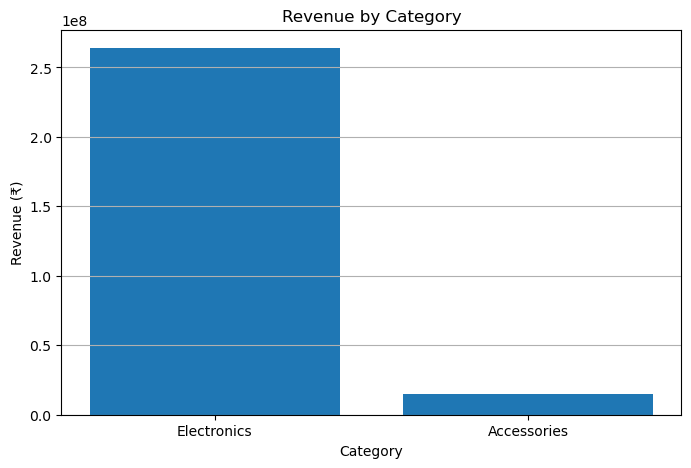

In [28]:
# Category revenue chart
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis["Revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")

plt.grid(axis="y")

plt.show()

In [29]:
# a Product Performance Matrix
revenue_median = product_analysis["Revenue"].median()

units_median = product_analysis["Units_Sold"].median()

In [30]:
def classify_product(row):

    high_revenue = row["Revenue"] >= revenue_median
    high_volume = row["Units_Sold"] >= units_median

    if high_revenue and high_volume:
        return "High Revenue / High Volume"

    elif high_revenue and not high_volume:
        return "High Revenue / Low Volume"

    elif not high_revenue and high_volume:
        return "Low Revenue / High Volume"

    else:
        return "Low Revenue / Low Volume"

In [31]:
product_analysis["Performance_Segment"] = (
    product_analysis.apply(
        classify_product,
        axis=1
    )
)

In [32]:
product_analysis[
    [
        "Revenue",
        "Units_Sold",
        "Performance_Segment"
    ]
]

,Revenue,Units_Sold,Performance_Segment
product,,,
Laptop,115261250.0,1917,High Revenue / High Volume
Smartphone,71852000.0,1944,High Revenue / High Volume
Tablet,50097000.0,1791,High Revenue / Low Volume
Monitor,26736750.0,1928,High Revenue / High Volume
Webcam,6120625.0,1894,Low Revenue / High Volume
Headphones,4321375.0,1873,Low Revenue / Low Volume
Keyboard,3398100.0,1835,Low Revenue / Low Volume
Mouse,1307200.0,1769,Low Revenue / Low Volume


In [33]:
# Counting products by segment
performance_counts = (
    product_analysis[
        "Performance_Segment"
    ].value_counts()
)

performance_counts

Performance_Segment
High Revenue / High Volume    3
Low Revenue / Low Volume      3
High Revenue / Low Volume     1
Low Revenue / High Volume     1
Name: count, dtype: int64

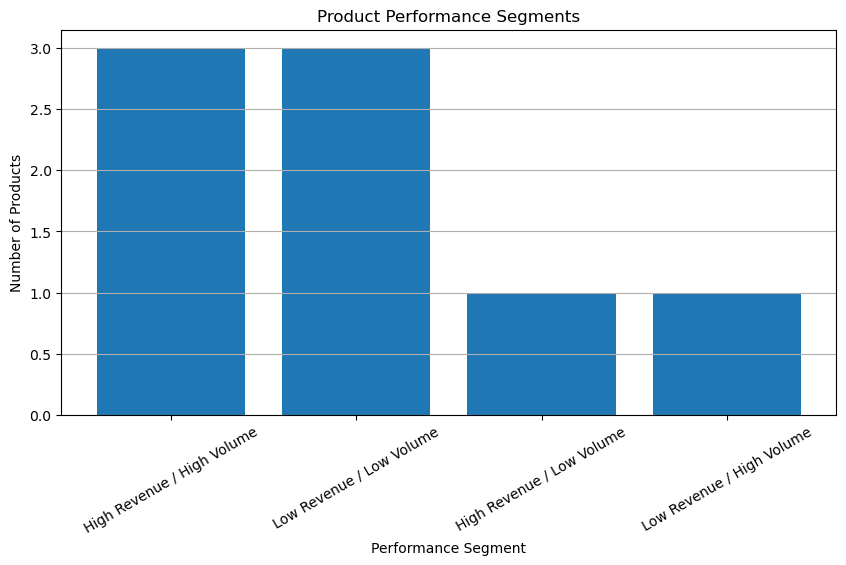

In [34]:
plt.figure(figsize=(10, 5))

plt.bar(
    performance_counts.index,
    performance_counts.values
)

plt.title("Product Performance Segments")
plt.xlabel("Performance Segment")
plt.ylabel("Number of Products")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

In [35]:
# Save
product_analysis.to_csv(
    "../data/processed/product_deep_dive.csv"
)

In [36]:
category_analysis.to_csv(
    "../data/processed/category_deep_dive.csv"
)

In [37]:
product_region.to_csv(
    "../data/processed/product_region_sales.csv"
)

Product & Category Analysis Insights
Product Revenue Performance

The highest-revenue product was Laptop, generating ₹11.53 crore and contributing 41.30% of total DataPulse revenue.

This makes Laptop the strongest individual revenue contributor.

Product Volume Performance

The highest-volume product was Smartphone, with 1,944 units sold.

The revenue leader and volume leader were different, showing that higher sales volume does not always mean higher revenue.

Pricing & Revenue

Laptop had the highest average unit price at approximately ₹65,000. Its high price, combined with sales volume, resulted in the highest overall revenue.

Discount Analysis

Headphones had the highest average discount at approximately 7.77%. However, its revenue contribution was relatively low at around 1.55%.

This does not prove that higher discounts cause lower sales; further analysis would be required.

Regional Product Performance

Laptop was the strongest product in all four regions:

North — ₹2.62 crore
South — ₹2.60 crore
East — ₹3.18 crore
West — ₹3.13 crore

This indicates consistently strong Laptop performance across regions.

Category Performance

Electronics was the highest-revenue category, generating ₹26.39 crore and contributing 94.57% of total revenue.

This shows that DataPulse revenue is heavily concentrated in Electronics.

Product Performance Matrix

The products were classified into four segments:

High Revenue / High Volume
High Revenue / Low Volume
Low Revenue / High Volume
Low Revenue / Low Volume

The largest groups were High Revenue / High Volume and Low Revenue / Low Volume, with 3 products each.

Key Business Insight

Laptop is the dominant revenue-driving product, while Smartphone leads in sales volume. This shows that product performance depends on both price and volume, not just units sold.

Business Recommendation

DataPulse should evaluate products using revenue, volume, pricing, and discounts together. High-volume but low-revenue products such as Webcam could be explored for pricing or cross-selling opportunities.

Analytical Limitation

The DataPulse dataset is synthetic, so these findings represent analytical practice rather than actual market behavior.